# Customer Churn Predictive Modeling

This notebook develops and evaluates machine-learning models for predicting customer churn.

The modeling workflow includes:

- Train, validation, and test dataset construction
- Leakage-aware preprocessing
- Baseline model development
- Logistic regression
- Tree-based models
- Class imbalance evaluation
- Model comparison and threshold analysis
- Feature importance and model interpretation

The primary objective is to identify customers at elevated risk of churn while maintaining a modeling workflow that generalizes to unseen customers.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.s3 import load_csv_from_s3
from src.features.build_features import build_features

## 1. Load Modeling Data

Load a fresh copy of the raw customer churn dataset to ensure that the modeling workflow begins from the original source data rather than the modified exploratory-analysis DataFrame.

In [3]:
df = load_csv_from_s3("raw/cell2celltrain.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 51,047
Columns: 58


## 2. Target Preparation and Data Splitting

Encode the churn target and divide the raw dataset into training, validation, and test sets before fitting any data-dependent preprocessing or feature-engineering steps.

In [4]:
df["ChurnTarget"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df["ChurnTarget"].value_counts())
print()
print(df["ChurnTarget"].value_counts(normalize=True).round(4))

ChurnTarget
0    36336
1    14711
Name: count, dtype: int64

ChurnTarget
0    0.7118
1    0.2882
Name: proportion, dtype: float64


In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["ChurnTarget"]
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["ChurnTarget"]
)

print(f"Training rows:   {len(train_df):,}")
print(f"Validation rows: {len(validation_df):,}")
print(f"Test rows:       {len(test_df):,}")

Training rows:   35,732
Validation rows: 7,657
Test rows:       7,658


In [6]:
for name, dataset in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Test", test_df)
]:
    churn_rate = dataset["ChurnTarget"].mean() * 100

    print(
        f"{name}: "
        f"{len(dataset):,} customers | "
        f"Churn rate: {churn_rate:.2f}%"
    )

Training: 35,732 customers | Churn rate: 28.82%
Validation: 7,657 customers | Churn rate: 28.82%
Test: 7,658 customers | Churn rate: 28.82%


### Training-Only Feature Thresholds

Data-dependent feature thresholds are calculated exclusively from the training set to prevent information from the validation and test sets from influencing feature construction.

In [7]:
low_usage_threshold = train_df["MonthlyMinutes"].quantile(0.25)
older_equipment_threshold = train_df["CurrentEquipmentDays"].quantile(0.50)

positive_overage = train_df.loc[
    train_df["OverageMinutes"] > 0,
    "OverageMinutes"
]

high_overage_threshold = positive_overage.quantile(2 / 3)

print(f"Low usage threshold: {low_usage_threshold:.2f} minutes")
print(
    f"Older equipment threshold: "
    f"{older_equipment_threshold:.2f} days"
)
print(
    f"High overage threshold: "
    f"{high_overage_threshold:.2f} minutes"
)

Low usage threshold: 158.00 minutes
Older equipment threshold: 329.00 days
High overage threshold: 65.00 minutes


In [8]:
import importlib
import src.features.build_features

importlib.reload(src.features.build_features)

from src.features.build_features import build_features

In [9]:
train_featured = build_features(
    train_df,
    low_usage_threshold=low_usage_threshold,
    older_equipment_threshold=older_equipment_threshold,
    high_overage_threshold=high_overage_threshold,
)

validation_featured = build_features(
    validation_df,
    low_usage_threshold=low_usage_threshold,
    older_equipment_threshold=older_equipment_threshold,
    high_overage_threshold=high_overage_threshold,
)

test_featured = build_features(
    test_df,
    low_usage_threshold=low_usage_threshold,
    older_equipment_threshold=older_equipment_threshold,
    high_overage_threshold=high_overage_threshold,
)

print(f"Training:   {train_featured.shape}")
print(f"Validation: {validation_featured.shape}")
print(f"Test:       {test_featured.shape}")

Training:   (35732, 67)
Validation: (7657, 67)
Test:       (7658, 67)


## 3. Predictor and Target Preparation

Separate predictor variables from the churn target and remove identifier and target-related columns that should not be available to the predictive models.

In [10]:
columns_to_exclude = [
    "CustomerID",
    "Churn",
    "ChurnTarget",
]

X_train = train_featured.drop(columns=columns_to_exclude)
y_train = train_featured["ChurnTarget"]

X_validation = validation_featured.drop(columns=columns_to_exclude)
y_validation = validation_featured["ChurnTarget"]

X_test = test_featured.drop(columns=columns_to_exclude)
y_test = test_featured["ChurnTarget"]

print(f"X_train:      {X_train.shape}")
print(f"y_train:      {y_train.shape}")

print(f"X_validation: {X_validation.shape}")
print(f"y_validation: {y_validation.shape}")

print(f"X_test:       {X_test.shape}")
print(f"y_test:       {y_test.shape}")

X_train:      (35732, 64)
y_train:      (35732,)
X_validation: (7657, 64)
y_validation: (7657,)
X_test:       (7658, 64)
y_test:       (7658,)


## 4. Preprocessing Strategy

Inspect predictor data types and categorical cardinality before constructing the machine-learning preprocessing pipeline.

In [11]:
numeric_columns = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["str", "object", "category"]
).columns.tolist()

print(f"Numeric predictors: {len(numeric_columns)}")
print(f"Categorical predictors: {len(categorical_columns)}")
print(f"Total predictors: {len(numeric_columns) + len(categorical_columns)}")

Numeric predictors: 42
Categorical predictors: 22
Total predictors: 64


In [12]:
categorical_cardinality = (
    X_train[categorical_columns]
    .nunique()
    .sort_values(ascending=False)
)

categorical_cardinality

ServiceArea                718
HandsetPrice                16
Occupation                   8
CreditRating                 7
PrizmCode                    4
MaritalStatus                3
RVOwner                      2
TruckOwner                   2
HandsetWebCapable            2
HandsetRefurbished           2
ChildrenInHH                 2
Homeownership                2
RespondsToMailOffers         2
BuysViaMailOrder             2
NewCellphoneUser             2
HasCreditCard                2
OwnsComputer                 2
NonUSTravel                  2
OptOutMailings               2
MadeCallToRetentionTeam      2
NotNewCellphoneUser          2
OwnsMotorcycle               2
dtype: int64

### High-Cardinality Service Area

`ServiceArea` contains substantially more categories than the other categorical predictors. Its training-set frequency distribution is examined before determining how rare service areas should be handled during preprocessing.

In [13]:
service_area_counts = X_train["ServiceArea"].value_counts()

print(f"Training service areas: {service_area_counts.size}")
print()

for threshold in [5, 10, 20, 50, 100]:
    rare_areas = service_area_counts[
        service_area_counts < threshold
    ]

    customers_in_rare_areas = rare_areas.sum()

    print(
        f"Fewer than {threshold:>3} customers: "
        f"{len(rare_areas):>3} areas | "
        f"{customers_in_rare_areas:,} customers "
        f"({customers_in_rare_areas / len(X_train) * 100:.2f}%)"
    )

Training service areas: 718

Fewer than   5 customers: 245 areas | 514 customers (1.44%)
Fewer than  10 customers: 353 areas | 1,220 customers (3.41%)
Fewer than  20 customers: 438 areas | 2,397 customers (6.71%)
Fewer than  50 customers: 549 areas | 5,919 customers (16.56%)
Fewer than 100 customers: 617 areas | 10,757 customers (30.10%)


### Rare Service Area Handling

Service areas represented by fewer than 10 customers in the training set are grouped into a common `Rare` category. The retained category set is learned exclusively from training data and subsequently applied unchanged to validation and test data.

In [14]:
service_area_counts = X_train["ServiceArea"].value_counts()

common_service_areas = set(
    service_area_counts[
        service_area_counts >= 10
    ].index
)

print(
    f"Original training categories: "
    f"{service_area_counts.size}"
)

print(
    f"Retained common categories: "
    f"{len(common_service_areas)}"
)

print(
    f"Grouped rare categories: "
    f"{service_area_counts.size - len(common_service_areas)}"
)

Original training categories: 718
Retained common categories: 365
Grouped rare categories: 353


In [15]:
X_train_processed = X_train.copy()
X_validation_processed = X_validation.copy()
X_test_processed = X_test.copy()


def group_service_areas(series, common_areas):
    return series.where(
        series.isna() | series.isin(common_areas),
        "Rare"
    )


X_train_processed["ServiceArea"] = group_service_areas(
    X_train_processed["ServiceArea"],
    common_service_areas
)

X_validation_processed["ServiceArea"] = group_service_areas(
    X_validation_processed["ServiceArea"],
    common_service_areas
)

X_test_processed["ServiceArea"] = group_service_areas(
    X_test_processed["ServiceArea"],
    common_service_areas
)

In [16]:
for name, dataset in [
    ("Training", X_train_processed),
    ("Validation", X_validation_processed),
    ("Test", X_test_processed),
]:
    print(
        f"{name}: "
        f"{dataset['ServiceArea'].nunique()} categories | "
        f"{(dataset['ServiceArea'] == 'Rare').sum():,} "
        f"customers grouped as Rare"
    )

Training: 366 categories | 1,220 customers grouped as Rare
Validation: 355 categories | 321 customers grouped as Rare
Test: 357 categories | 318 customers grouped as Rare


In [17]:
for name, dataset in [
    ("Training", X_train_processed),
    ("Validation", X_validation_processed),
    ("Test", X_test_processed),
]:
    print(
        f"{name}: "
        f"{dataset['ServiceArea'].nunique()} categories | "
        f"{(dataset['ServiceArea'] == 'Rare').sum():,} Rare | "
        f"{dataset['ServiceArea'].isna().sum():,} missing"
    )

Training: 366 categories | 1,220 Rare | 17 missing
Validation: 355 categories | 321 Rare | 4 missing
Test: 357 categories | 318 Rare | 3 missing


### Modeling Preprocessing Pipeline

Construct a preprocessing pipeline that handles missing numeric and categorical values, standardizes numeric predictors, and one-hot encodes categorical predictors.

All preprocessing parameters will be fitted exclusively on the training data and subsequently applied unchanged to validation and test data.

In [18]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_columns
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_columns
        ),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

### Apply Preprocessing

Fit the preprocessing pipeline exclusively on the training data. Apply the learned transformations unchanged to the validation and test sets.

In [19]:
X_train_transformed = preprocessor.fit_transform(
    X_train_processed
)

X_validation_transformed = preprocessor.transform(
    X_validation_processed
)

X_test_transformed = preprocessor.transform(
    X_test_processed
)

print(
    f"Training transformed:   "
    f"{X_train_transformed.shape}"
)

print(
    f"Validation transformed: "
    f"{X_validation_transformed.shape}"
)

print(
    f"Test transformed:       "
    f"{X_test_transformed.shape}"
)

Training transformed:   (35732, 478)
Validation transformed: (7657, 478)
Test transformed:       (7658, 478)


In [20]:
print(
    "Training NaNs:",
    X_train_transformed.data[
        np.isnan(X_train_transformed.data)
    ].size
    if hasattr(X_train_transformed, "data")
    else np.isnan(X_train_transformed).sum()
)

print(
    "Validation NaNs:",
    X_validation_transformed.data[
        np.isnan(X_validation_transformed.data)
    ].size
    if hasattr(X_validation_transformed, "data")
    else np.isnan(X_validation_transformed).sum()
)

print(
    "Test NaNs:",
    X_test_transformed.data[
        np.isnan(X_test_transformed.data)
    ].size
    if hasattr(X_test_transformed, "data")
    else np.isnan(X_test_transformed).sum()
)

Training NaNs: 0
Validation NaNs: 0
Test NaNs: 0


## 5. Baseline Model

Establish a naive majority-class baseline that predicts every customer as the most common training-set class. More sophisticated models must provide meaningful improvement beyond this baseline.

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

In [22]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train_transformed,
    y_train
)

dummy_predictions = dummy_model.predict(
    X_validation_transformed
)

dummy_probabilities = dummy_model.predict_proba(
    X_validation_transformed
)[:, 1]

dummy_accuracy = accuracy_score(
    y_validation,
    dummy_predictions
)

dummy_precision = precision_score(
    y_validation,
    dummy_predictions,
    zero_division=0
)

dummy_recall = recall_score(
    y_validation,
    dummy_predictions,
    zero_division=0
)

dummy_f1 = f1_score(
    y_validation,
    dummy_predictions,
    zero_division=0
)

dummy_roc_auc = roc_auc_score(
    y_validation,
    dummy_probabilities
)

print(f"Accuracy:  {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall:    {dummy_recall:.4f}")
print(f"F1 Score:  {dummy_f1:.4f}")
print(f"ROC-AUC:   {dummy_roc_auc:.4f}")

Accuracy:  0.7118
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
ROC-AUC:   0.5000


## 6. Logistic Regression

Train a logistic regression classifier as the first predictive model. Logistic regression provides an interpretable benchmark for determining whether customer characteristics contain useful signal beyond the majority-class baseline.

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_transformed,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_validation_transformed
)

logistic_probabilities = logistic_model.predict_proba(
    X_validation_transformed
)[:, 1]

In [25]:
logistic_accuracy = accuracy_score(
    y_validation,
    logistic_predictions
)

logistic_precision = precision_score(
    y_validation,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_validation,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_validation,
    logistic_predictions,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_validation,
    logistic_probabilities
)

print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1 Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")

Accuracy:  0.7088
Precision: 0.4582
Recall:    0.0571
F1 Score:  0.1015
ROC-AUC:   0.6049


In [26]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    classification_report,
)

### Logistic Regression Validation Performance

Evaluate logistic regression using probability-based and classification-based metrics, including PR-AUC and the confusion matrix, to better understand performance on the churn class.

In [27]:
logistic_pr_auc = average_precision_score(
    y_validation,
    logistic_probabilities
)

logistic_confusion = confusion_matrix(
    y_validation,
    logistic_predictions
)

print(f"ROC-AUC: {logistic_roc_auc:.4f}")
print(f"PR-AUC:  {logistic_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(logistic_confusion)

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        logistic_predictions,
        target_names=["No Churn", "Churn"],
        digits=4,
        zero_division=0,
    )
)

ROC-AUC: 0.6049
PR-AUC:  0.3702

Confusion Matrix:
[[5301  149]
 [2081  126]]

Classification Report:
              precision    recall  f1-score   support

    No Churn     0.7181    0.9727    0.8262      5450
       Churn     0.4582    0.0571    0.1015      2207

    accuracy                         0.7088      7657
   macro avg     0.5881    0.5149    0.4639      7657
weighted avg     0.6432    0.7088    0.6173      7657



## 7. Decision Tree

Train a decision tree classifier to capture nonlinear relationships and interactions between customer characteristics that logistic regression may not represent effectively.

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

decision_tree.fit(
    X_train_transformed,
    y_train
)

tree_predictions = decision_tree.predict(
    X_validation_transformed
)

tree_probabilities = decision_tree.predict_proba(
    X_validation_transformed
)[:, 1]

In [30]:
tree_accuracy = accuracy_score(
    y_validation,
    tree_predictions
)

tree_precision = precision_score(
    y_validation,
    tree_predictions,
    zero_division=0
)

tree_recall = recall_score(
    y_validation,
    tree_predictions,
    zero_division=0
)

tree_f1 = f1_score(
    y_validation,
    tree_predictions,
    zero_division=0
)

tree_roc_auc = roc_auc_score(
    y_validation,
    tree_probabilities
)

tree_pr_auc = average_precision_score(
    y_validation,
    tree_probabilities
)

print(f"Accuracy:  {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall:    {tree_recall:.4f}")
print(f"F1 Score:  {tree_f1:.4f}")
print(f"ROC-AUC:   {tree_roc_auc:.4f}")
print(f"PR-AUC:    {tree_pr_auc:.4f}")

Accuracy:  0.7154
Precision: 0.5707
Recall:    0.0512
F1 Score:  0.0940
ROC-AUC:   0.6267
PR-AUC:    0.3834


## 8. Random Forest

Train a random forest classifier to capture nonlinear relationships and feature interactions while reducing the instability and overfitting associated with a single decision tree.

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)

random_forest.fit(
    X_train_transformed,
    y_train
)

rf_predictions = random_forest.predict(
    X_validation_transformed
)

rf_probabilities = random_forest.predict_proba(
    X_validation_transformed
)[:, 1]

In [33]:
rf_accuracy = accuracy_score(
    y_validation,
    rf_predictions
)

rf_precision = precision_score(
    y_validation,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_validation,
    rf_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_validation,
    rf_predictions,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_validation,
    rf_probabilities
)

rf_pr_auc = average_precision_score(
    y_validation,
    rf_probabilities
)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")
print(f"PR-AUC:    {rf_pr_auc:.4f}")

Accuracy:  0.7158
Precision: 0.6782
Recall:    0.0267
F1 Score:  0.0514
ROC-AUC:   0.6476
PR-AUC:    0.4178


## 9. Gradient Boosting

Train a gradient boosting classifier to model nonlinear customer relationships by sequentially combining decision trees, with each stage improving upon errors made by earlier stages.

In [34]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [39]:
gradient_boosting = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42,
)

gradient_boosting.fit(
    X_train_dense,
    y_train
)

gb_predictions = gradient_boosting.predict(
    X_validation_dense
)

gb_probabilities = gradient_boosting.predict_proba(
    X_validation_dense
)[:, 1]

In [42]:
gradient_boosting = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42,
)

gradient_boosting.fit(
    X_train_dense,
    y_train
)

gb_predictions = gradient_boosting.predict(
    X_validation_dense
)

gb_probabilities = gradient_boosting.predict_proba(
    X_validation_dense
)[:, 1]

In [43]:
X_train_dense = X_train_transformed.toarray()
X_validation_dense = X_validation_transformed.toarray()

print(f"Training dense:   {X_train_dense.shape}")
print(f"Validation dense: {X_validation_dense.shape}")

print(
    f"Training memory: "
    f"{X_train_dense.nbytes / (1024 ** 2):.2f} MB"
)

Training dense:   (35732, 478)
Validation dense: (7657, 478)
Training memory: 130.31 MB


In [44]:
gb_accuracy = accuracy_score(
    y_validation,
    gb_predictions
)

gb_precision = precision_score(
    y_validation,
    gb_predictions,
    zero_division=0
)

gb_recall = recall_score(
    y_validation,
    gb_predictions,
    zero_division=0
)

gb_f1 = f1_score(
    y_validation,
    gb_predictions,
    zero_division=0
)

gb_roc_auc = roc_auc_score(
    y_validation,
    gb_probabilities
)

gb_pr_auc = average_precision_score(
    y_validation,
    gb_probabilities
)

print(f"Accuracy:  {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall:    {gb_recall:.4f}")
print(f"F1 Score:  {gb_f1:.4f}")
print(f"ROC-AUC:   {gb_roc_auc:.4f}")
print(f"PR-AUC:    {gb_pr_auc:.4f}")

Accuracy:  0.7196
Precision: 0.5926
Recall:    0.0870
F1 Score:  0.1517
ROC-AUC:   0.6639
PR-AUC:    0.4403


## 10. Model Comparison

Compare validation performance across candidate models using both threshold-dependent classification metrics and threshold-independent probability-ranking metrics.

In [45]:
model_results = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
    ],
    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        gb_accuracy,
    ],
    "Precision": [
        dummy_precision,
        logistic_precision,
        tree_precision,
        rf_precision,
        gb_precision,
    ],
    "Recall": [
        dummy_recall,
        logistic_recall,
        tree_recall,
        rf_recall,
        gb_recall,
    ],
    "F1": [
        dummy_f1,
        logistic_f1,
        tree_f1,
        rf_f1,
        gb_f1,
    ],
    "ROC_AUC": [
        dummy_roc_auc,
        logistic_roc_auc,
        tree_roc_auc,
        rf_roc_auc,
        gb_roc_auc,
    ],
    "PR_AUC": [
        y_train.mean(),
        logistic_pr_auc,
        tree_pr_auc,
        rf_pr_auc,
        gb_pr_auc,
    ],
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Baseline,0.7118,0.0000,0.0000,0.0000,0.5000,0.2882
1,Logistic Regression,0.7088,0.4582,0.0571,0.1015,0.6049,0.3702
2,Decision Tree,0.7154,0.5707,0.0512,0.0940,0.6267,0.3834
3,Random Forest,0.7158,0.6782,0.0267,0.0514,0.6476,0.4178
4,Gradient Boosting,0.7196,0.5926,0.0870,0.1517,0.6639,0.4403


In [46]:
gb_train_probabilities = gradient_boosting.predict_proba(
    X_train_dense
)[:, 1]

gb_train_roc_auc = roc_auc_score(
    y_train,
    gb_train_probabilities
)

gb_train_pr_auc = average_precision_score(
    y_train,
    gb_train_probabilities
)

print(f"Training ROC-AUC:   {gb_train_roc_auc:.4f}")
print(f"Validation ROC-AUC: {gb_roc_auc:.4f}")
print(
    f"ROC-AUC gap:        "
    f"{gb_train_roc_auc - gb_roc_auc:.4f}"
)

print()

print(f"Training PR-AUC:    {gb_train_pr_auc:.4f}")
print(f"Validation PR-AUC:  {gb_pr_auc:.4f}")
print(
    f"PR-AUC gap:         "
    f"{gb_train_pr_auc - gb_pr_auc:.4f}"
)

Training ROC-AUC:   0.7303
Validation ROC-AUC: 0.6639
ROC-AUC gap:        0.0665

Training PR-AUC:    0.5304
Validation PR-AUC:  0.4403
PR-AUC gap:         0.0901


### Regularized Gradient Boosting

Evaluate a more strongly regularized gradient boosting model to reduce the observed gap between training and validation performance.

In [47]:
gb_regularized = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=10,
    min_samples_leaf=60,
    l2_regularization=3.0,
    random_state=42,
)

gb_regularized.fit(
    X_train_dense,
    y_train
)

gb_reg_predictions = gb_regularized.predict(
    X_validation_dense
)

gb_reg_probabilities = gb_regularized.predict_proba(
    X_validation_dense
)[:, 1]

In [48]:
gb_reg_accuracy = accuracy_score(
    y_validation,
    gb_reg_predictions
)

gb_reg_precision = precision_score(
    y_validation,
    gb_reg_predictions,
    zero_division=0
)

gb_reg_recall = recall_score(
    y_validation,
    gb_reg_predictions,
    zero_division=0
)

gb_reg_f1 = f1_score(
    y_validation,
    gb_reg_predictions,
    zero_division=0
)

gb_reg_roc_auc = roc_auc_score(
    y_validation,
    gb_reg_probabilities
)

gb_reg_pr_auc = average_precision_score(
    y_validation,
    gb_reg_probabilities
)

print(f"Accuracy:  {gb_reg_accuracy:.4f}")
print(f"Precision: {gb_reg_precision:.4f}")
print(f"Recall:    {gb_reg_recall:.4f}")
print(f"F1 Score:  {gb_reg_f1:.4f}")
print(f"ROC-AUC:   {gb_reg_roc_auc:.4f}")
print(f"PR-AUC:    {gb_reg_pr_auc:.4f}")

Accuracy:  0.7170
Precision: 0.5671
Recall:    0.0766
F1 Score:  0.1349
ROC-AUC:   0.6641
PR-AUC:    0.4384


In [49]:
gb_reg_train_probabilities = gb_regularized.predict_proba(
    X_train_dense
)[:, 1]

gb_reg_train_roc_auc = roc_auc_score(
    y_train,
    gb_reg_train_probabilities
)

gb_reg_train_pr_auc = average_precision_score(
    y_train,
    gb_reg_train_probabilities
)

print(f"Training ROC-AUC:   {gb_reg_train_roc_auc:.4f}")
print(f"Validation ROC-AUC: {gb_reg_roc_auc:.4f}")
print(
    f"ROC-AUC gap:        "
    f"{gb_reg_train_roc_auc - gb_reg_roc_auc:.4f}"
)

print()

print(f"Training PR-AUC:    {gb_reg_train_pr_auc:.4f}")
print(f"Validation PR-AUC:  {gb_reg_pr_auc:.4f}")
print(
    f"PR-AUC gap:         "
    f"{gb_reg_train_pr_auc - gb_reg_pr_auc:.4f}"
)

Training ROC-AUC:   0.7144
Validation ROC-AUC: 0.6641
ROC-AUC gap:        0.0503

Training PR-AUC:    0.5048
Validation PR-AUC:  0.4384
PR-AUC gap:         0.0665


## 11. Class Imbalance Experiments

Evaluate class-weighted models to determine whether assigning greater importance to churn observations improves the model's ability to identify customers at risk of churn.

In [50]:
weighted_logistic = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
)

weighted_logistic.fit(
    X_train_transformed,
    y_train
)

weighted_logistic_predictions = weighted_logistic.predict(
    X_validation_transformed
)

weighted_logistic_probabilities = weighted_logistic.predict_proba(
    X_validation_transformed
)[:, 1]

In [51]:
weighted_logistic_accuracy = accuracy_score(
    y_validation,
    weighted_logistic_predictions
)

weighted_logistic_precision = precision_score(
    y_validation,
    weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_recall = recall_score(
    y_validation,
    weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_f1 = f1_score(
    y_validation,
    weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_roc_auc = roc_auc_score(
    y_validation,
    weighted_logistic_probabilities
)

weighted_logistic_pr_auc = average_precision_score(
    y_validation,
    weighted_logistic_probabilities
)

print(f"Accuracy:  {weighted_logistic_accuracy:.4f}")
print(f"Precision: {weighted_logistic_precision:.4f}")
print(f"Recall:    {weighted_logistic_recall:.4f}")
print(f"F1 Score:  {weighted_logistic_f1:.4f}")
print(f"ROC-AUC:   {weighted_logistic_roc_auc:.4f}")
print(f"PR-AUC:    {weighted_logistic_pr_auc:.4f}")

Accuracy:  0.5759
Precision: 0.3540
Recall:    0.5714
F1 Score:  0.4372
ROC-AUC:   0.6044
PR-AUC:    0.3690


In [52]:
weighted_random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

weighted_random_forest.fit(
    X_train_transformed,
    y_train
)

weighted_rf_predictions = weighted_random_forest.predict(
    X_validation_transformed
)

weighted_rf_probabilities = weighted_random_forest.predict_proba(
    X_validation_transformed
)[:, 1]

In [53]:
weighted_rf_accuracy = accuracy_score(
    y_validation,
    weighted_rf_predictions
)

weighted_rf_precision = precision_score(
    y_validation,
    weighted_rf_predictions,
    zero_division=0
)

weighted_rf_recall = recall_score(
    y_validation,
    weighted_rf_predictions,
    zero_division=0
)

weighted_rf_f1 = f1_score(
    y_validation,
    weighted_rf_predictions,
    zero_division=0
)

weighted_rf_roc_auc = roc_auc_score(
    y_validation,
    weighted_rf_probabilities
)

weighted_rf_pr_auc = average_precision_score(
    y_validation,
    weighted_rf_probabilities
)

print(f"Accuracy:  {weighted_rf_accuracy:.4f}")
print(f"Precision: {weighted_rf_precision:.4f}")
print(f"Recall:    {weighted_rf_recall:.4f}")
print(f"F1 Score:  {weighted_rf_f1:.4f}")
print(f"ROC-AUC:   {weighted_rf_roc_auc:.4f}")
print(f"PR-AUC:    {weighted_rf_pr_auc:.4f}")

Accuracy:  0.5917
Precision: 0.3772
Recall:    0.6398
F1 Score:  0.4746
ROC-AUC:   0.6462
PR-AUC:    0.4192


## 12. Classification Threshold Analysis

Evaluate how different probability thresholds change the precision-recall tradeoff. The default 0.50 threshold is not assumed to be optimal for customer churn intervention.

In [54]:
threshold_results = []

for threshold in np.arange(0.20, 0.51, 0.05):
    predictions = (
        gb_reg_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Precision": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "CustomersFlagged": predictions.sum(),
        "FlaggedPercent": predictions.mean() * 100,
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round({
    "Threshold": 2,
    "Accuracy": 4,
    "Precision": 4,
    "Recall": 4,
    "F1": 4,
    "FlaggedPercent": 2,
})

,Threshold,Accuracy,Precision,Recall,F1,CustomersFlagged,FlaggedPercent
0,0.20,0.4636,0.3356,0.8786,0.4857,5778,75.46
1,0.25,0.5419,0.3625,0.7771,0.4944,4731,61.79
2,0.30,0.6253,0.4006,0.6044,0.4818,3330,43.49
3,0.35,0.6799,0.4409,0.4123,0.4261,2064,26.96
4,0.40,0.7076,0.4861,0.2528,0.3326,1148,14.99
5,0.45,0.7192,0.5481,0.1473,0.2321,593,7.74
6,0.50,0.7170,0.5671,0.0766,0.1349,298,3.89


### Fine-Grained Threshold Evaluation

Evaluate classification performance across a finer range of probability thresholds to identify candidate operating points for customer retention targeting. Threshold selection is performed exclusively using validation data.

In [55]:
fine_threshold_results = []

for threshold in np.arange(0.10, 0.61, 0.01):
    predictions = (
        gb_reg_probabilities >= threshold
    ).astype(int)

    fine_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Precision": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "CustomersFlagged": predictions.sum(),
        "FlaggedPercent": predictions.mean() * 100,
    })

fine_threshold_results = pd.DataFrame(
    fine_threshold_results
)

In [56]:
best_f1_row = fine_threshold_results.loc[
    fine_threshold_results["F1"].idxmax()
]

print("Highest-F1 Threshold")
print("--------------------")
print(f"Threshold:         {best_f1_row['Threshold']:.2f}")
print(f"Accuracy:          {best_f1_row['Accuracy']:.4f}")
print(f"Precision:         {best_f1_row['Precision']:.4f}")
print(f"Recall:            {best_f1_row['Recall']:.4f}")
print(f"F1 Score:          {best_f1_row['F1']:.4f}")
print(f"Customers Flagged: {int(best_f1_row['CustomersFlagged']):,}")
print(f"Flagged Percent:   {best_f1_row['FlaggedPercent']:.2f}%")

Highest-F1 Threshold
--------------------
Threshold:         0.24
Accuracy:          0.5263
Precision:         0.3573
Recall:            0.8056
F1 Score:          0.4951
Customers Flagged: 4,976
Flagged Percent:   64.99%


### Retention Campaign Capacity Analysis

Evaluate model performance under different retention-team capacities by targeting customers with the highest predicted churn probabilities. This translates model performance into an operational customer-retention scenario.

In [57]:
capacity_results = []

for capacity in [0.10, 0.20, 0.30, 0.40]:
    
    threshold = np.quantile(
        gb_reg_probabilities,
        1 - capacity
    )

    predictions = (
        gb_reg_probabilities >= threshold
    ).astype(int)

    customers_flagged = predictions.sum()
    churners_captured = (
        (predictions == 1) & (y_validation.values == 1)
    ).sum()

    precision = precision_score(
        y_validation,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        predictions,
        zero_division=0
    )

    capacity_results.append({
        "TargetCapacity": capacity,
        "Threshold": threshold,
        "CustomersFlagged": customers_flagged,
        "ChurnersCaptured": churners_captured,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    })

capacity_results = pd.DataFrame(capacity_results)

capacity_results["TargetCapacity"] = (
    capacity_results["TargetCapacity"] * 100
)

capacity_results.round({
    "TargetCapacity": 0,
    "Threshold": 3,
    "Precision": 4,
    "Recall": 4,
    "F1": 4,
})

,TargetCapacity,Threshold,CustomersFlagged,ChurnersCaptured,Precision,Recall,F1
0,10.0,0.433,766,404,0.5274,0.1831,0.2718
1,20.0,0.377,1532,713,0.4654,0.3231,0.3814
2,30.0,0.340,2297,985,0.4288,0.4463,0.4374
3,40.0,0.310,3063,1250,0.4081,0.5664,0.4744


### Lift Analysis

Calculate lift to measure how effectively the model concentrates churners within the highest-risk customer segments relative to targeting customers without model-based prioritization.

In [58]:
validation_churn_rate = y_validation.mean()

capacity_results["Lift"] = (
    capacity_results["Precision"]
    / validation_churn_rate
)

capacity_results["ChurnCapturePercent"] = (
    capacity_results["Recall"] * 100
)

capacity_results[
    [
        "TargetCapacity",
        "CustomersFlagged",
        "ChurnersCaptured",
        "Precision",
        "ChurnCapturePercent",
        "Lift",
    ]
].round({
    "TargetCapacity": 0,
    "Precision": 4,
    "ChurnCapturePercent": 2,
    "Lift": 2,
})

,TargetCapacity,CustomersFlagged,ChurnersCaptured,Precision,ChurnCapturePercent,Lift
0,10.0,766,404,0.5274,18.31,1.83
1,20.0,1532,713,0.4654,32.31,1.61
2,30.0,2297,985,0.4288,44.63,1.49
3,40.0,3063,1250,0.4081,56.64,1.42


In [59]:
capacity_results["RandomExpectedCapturePercent"] = (
    capacity_results["TargetCapacity"]
)

capacity_results["CaptureGainVsRandom"] = (
    capacity_results["ChurnCapturePercent"]
    - capacity_results["RandomExpectedCapturePercent"]
)

capacity_results[
    [
        "TargetCapacity",
        "ChurnCapturePercent",
        "RandomExpectedCapturePercent",
        "CaptureGainVsRandom",
        "Lift",
    ]
].round(2)

,TargetCapacity,ChurnCapturePercent,RandomExpectedCapturePercent,CaptureGainVsRandom,Lift
0,10.0,18.31,10.0,8.31,1.83
1,20.0,32.31,20.0,12.31,1.61
2,30.0,44.63,30.0,14.63,1.49
3,40.0,56.64,40.0,16.64,1.42


### Cumulative Gains Curve

Visualize the percentage of churners captured as progressively larger portions of the highest-risk customer population are targeted. The random-targeting line provides a baseline for evaluating the model's prioritization ability.

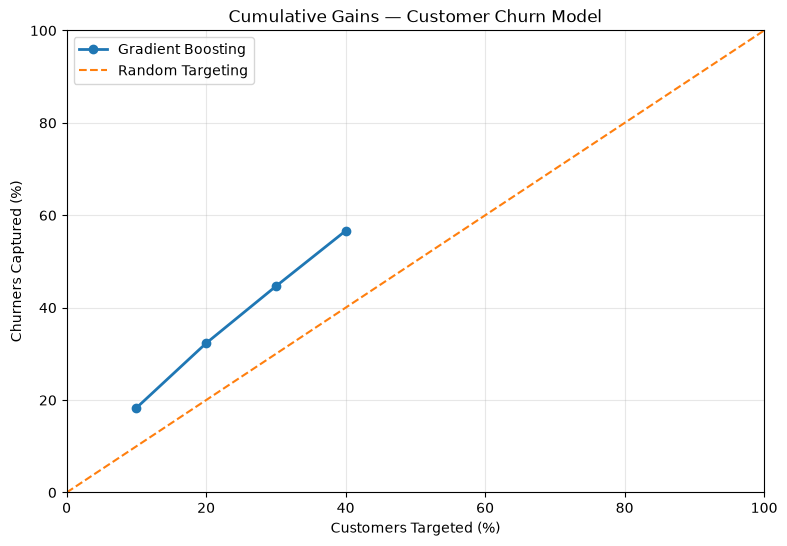

In [60]:
plt.figure(figsize=(9, 6))

plt.plot(
    capacity_results["TargetCapacity"],
    capacity_results["ChurnCapturePercent"],
    marker="o",
    linewidth=2,
    label="Gradient Boosting"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Random Targeting"
)

plt.xlabel("Customers Targeted (%)")
plt.ylabel("Churners Captured (%)")
plt.title("Cumulative Gains — Customer Churn Model")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

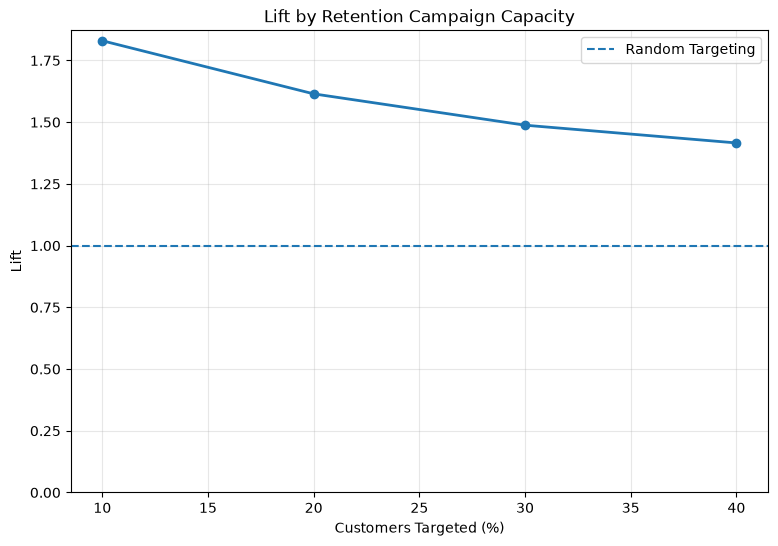

In [61]:
plt.figure(figsize=(9, 6))

plt.plot(
    capacity_results["TargetCapacity"],
    capacity_results["Lift"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Random Targeting"
)

plt.xlabel("Customers Targeted (%)")
plt.ylabel("Lift")
plt.title("Lift by Retention Campaign Capacity")
plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [62]:
from sklearn.inspection import permutation_importance

## 13. Model Interpretability

Evaluate permutation feature importance to identify which customer characteristics contribute most strongly to the model's ability to rank churn risk.

Permutation importance is measured on validation data rather than training data to better reflect the model's reliance on features when generalizing to unseen customers.

In [63]:
from sklearn.preprocessing import FunctionTransformer

In [64]:
def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X


interpretation_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "to_dense",
            FunctionTransformer(to_dense)
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=10,
                min_samples_leaf=60,
                l2_regularization=3.0,
                random_state=42,
            )
        ),
    ]
)

interpretation_pipeline.fit(
    X_train_processed,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('to_dense', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](64,)","['MonthlyRevenue','MonthlyMinutes','TotalRecurringCharge',..., 'HighOverage','LowUsageOlderEquipment','HighRiskHandset']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,64
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (d

In [65]:
pipeline_probabilities = interpretation_pipeline.predict_proba(
    X_validation_processed
)[:, 1]

pipeline_roc_auc = roc_auc_score(
    y_validation,
    pipeline_probabilities
)

pipeline_pr_auc = average_precision_score(
    y_validation,
    pipeline_probabilities
)

print(f"Pipeline ROC-AUC: {pipeline_roc_auc:.4f}")
print(f"Pipeline PR-AUC:  {pipeline_pr_auc:.4f}")

Pipeline ROC-AUC: 0.6641
Pipeline PR-AUC:  0.4384


### Permutation Feature Importance

Measure the decrease in validation ROC-AUC after independently shuffling each original predictor. Features that cause larger decreases in model performance are interpreted as more important to the model's predictive ranking ability.

In [66]:
permutation_results = permutation_importance(
    interpretation_pipeline,
    X_validation_processed,
    y_validation,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

In [67]:
feature_importance = pd.DataFrame({
    "Feature": X_validation_processed.columns,
    "ImportanceMean": permutation_results.importances_mean,
    "ImportanceStd": permutation_results.importances_std,
})

feature_importance = (
    feature_importance
    .sort_values(
        "ImportanceMean",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance.head(15).round(4)

,Feature,ImportanceMean,ImportanceStd
0,MonthsInService,0.0348,0.0023
1,CurrentEquipmentDays,0.0314,0.0036
2,MinutesPerRevenueDollar,0.0197,0.0027
3,PercChangeMinutes,0.0195,0.0032
4,TotalRecurringCharge,0.0105,0.0010
5,RetentionCalls,0.0058,0.0012
6,CreditRating,0.0052,0.0010
7,UniqueSubs,0.0049,0.0015
8,EquipmentAgeToTenure,0.0044,0.0008
9,AgeHH1,0.0034,0.0012


### Most Important Churn Predictors

Visualize the predictors with the largest permutation importance values to identify the customer characteristics most influential to the model's validation-set churn-risk ranking.

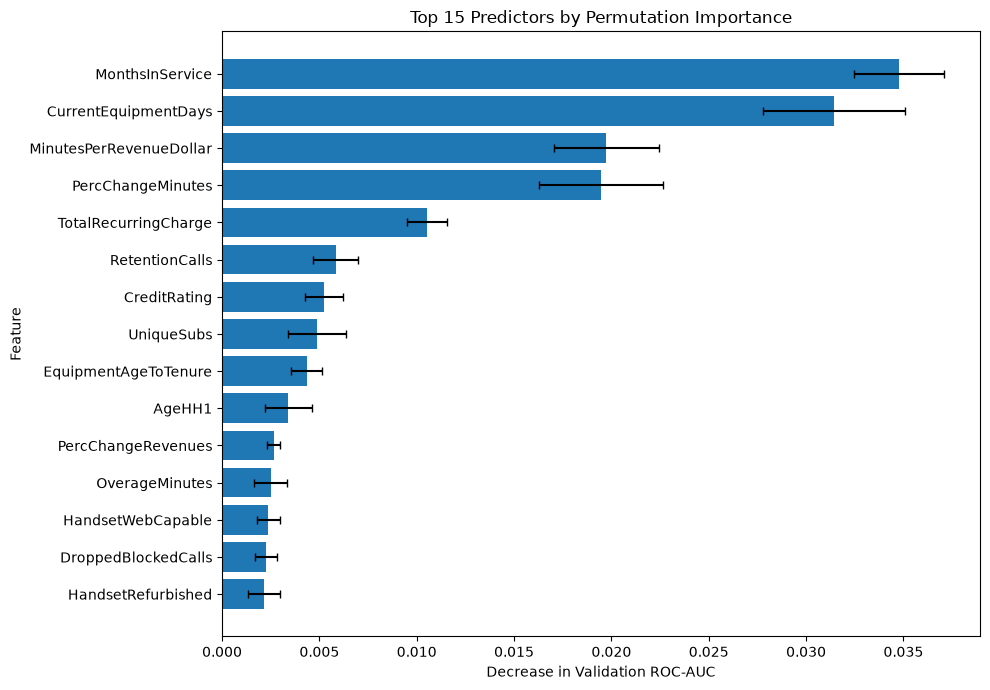

In [68]:
top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "ImportanceMean",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["ImportanceMean"],
    xerr=top_features["ImportanceStd"],
    capsize=3
)

plt.xlabel("Decrease in Validation ROC-AUC")
plt.ylabel("Feature")
plt.title(
    "Top 15 Predictors by Permutation Importance"
)

plt.tight_layout()
plt.show()

In [69]:
engineered_features = [
    "MinutesPerRevenueDollar",
    "EquipmentAgeToTenure",
    "TotalCallActivity",
    "LowUsage",
    "OlderEquipment",
    "HighOverage",
    "LowUsageOlderEquipment",
    "HighRiskHandset",
]

engineered_importance = (
    feature_importance[
        feature_importance["Feature"].isin(
            engineered_features
        )
    ]
    .sort_values(
        "ImportanceMean",
        ascending=False
    )
    .reset_index(drop=True)
)

engineered_importance.round(4)

,Feature,ImportanceMean,ImportanceStd
0,MinutesPerRevenueDollar,0.0197,0.0027
1,EquipmentAgeToTenure,0.0044,0.0008
2,HighRiskHandset,0.0000,0.0000
3,OlderEquipment,0.0000,0.0000
4,HighOverage,0.0000,0.0000
5,LowUsageOlderEquipment,0.0000,0.0000
6,LowUsage,0.0000,0.0000
7,TotalCallActivity,-0.0001,0.0001


In [70]:
from sklearn.inspection import PartialDependenceDisplay

### Partial Dependence Analysis

Examine how predicted churn risk changes across important numeric predictors while averaging over the other customer characteristics in the validation population.

Partial dependence describes patterns learned by the model and should not be interpreted as evidence that changing a feature would causally change customer churn.

In [71]:
pdp_features = [
    "MonthsInService",
    "CurrentEquipmentDays",
    "MinutesPerRevenueDollar",
    "PercChangeMinutes",
]

In [73]:
X_validation_pdp = X_validation_processed.copy()

for column in numeric_columns:
    X_validation_pdp[column] = (
        X_validation_pdp[column].astype(float)
    )

In [74]:
X_validation_pdp[
    [
        "MonthsInService",
        "CurrentEquipmentDays",
        "MinutesPerRevenueDollar",
        "PercChangeMinutes",
    ]
].dtypes

MonthsInService            float64
CurrentEquipmentDays       float64
MinutesPerRevenueDollar    float64
PercChangeMinutes          float64
dtype: object

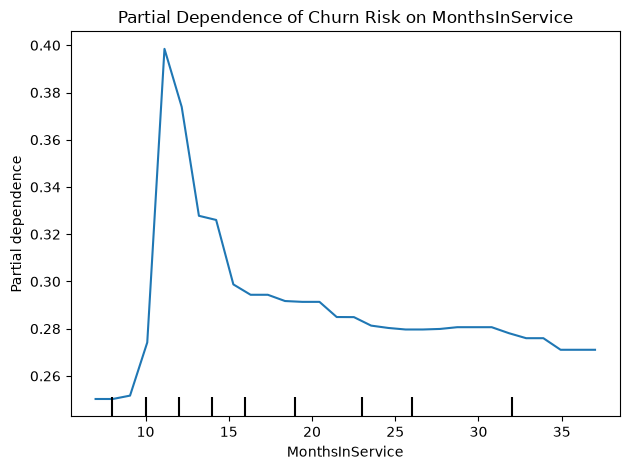

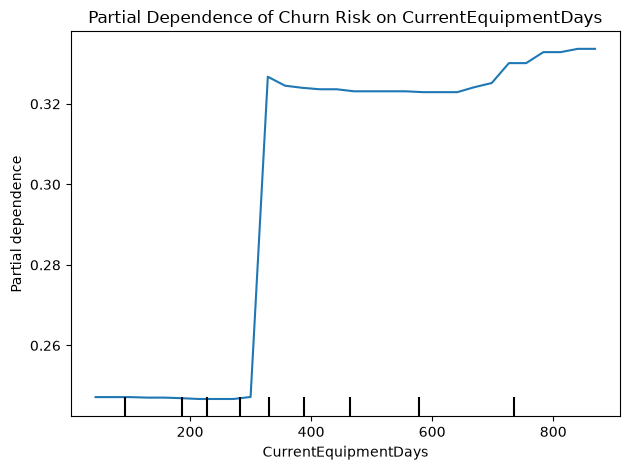

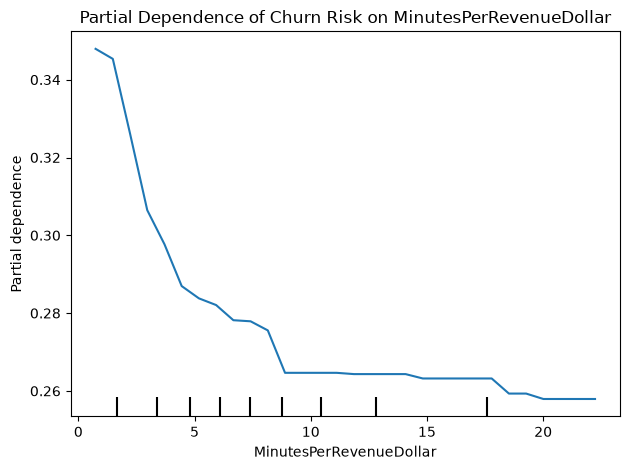

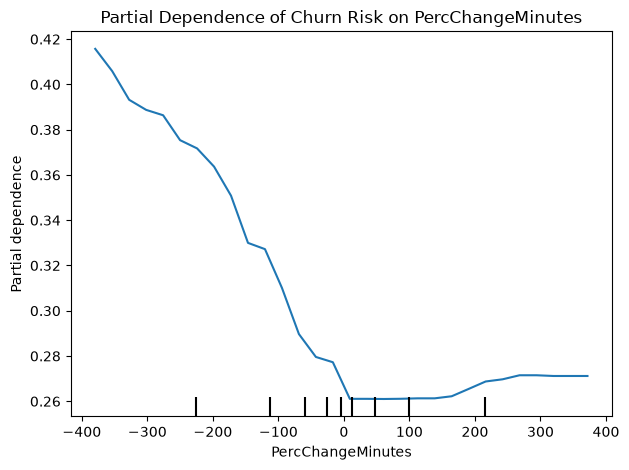

In [75]:
for feature in pdp_features:

    PartialDependenceDisplay.from_estimator(
        interpretation_pipeline,
        X_validation_pdp,
        features=[feature],
        kind="average",
        grid_resolution=30,
    )

    plt.title(
        f"Partial Dependence of Churn Risk on {feature}"
    )

    plt.tight_layout()
    plt.show()

### Interpretation Findings

Permutation importance and partial dependence analysis identified several notable patterns in the Gradient Boosting model:

- **Customer tenure (`MonthsInService`)** was the most influential predictor. Predicted churn risk was elevated around the first year of service and generally declined among longer-tenured customers.
- **Equipment age (`CurrentEquipmentDays`)** was the second-most influential predictor. Predicted churn risk increased substantially for customers with older equipment, with a notable transition around approximately 330 days.
- **Minutes per revenue dollar (`MinutesPerRevenueDollar`)**, an engineered feature, was the third-most influential predictor. Lower values were associated with higher predicted churn risk.
- **Change in monthly usage (`PercChangeMinutes`)** showed a strong relationship with predicted churn risk. Large declines in usage were associated with substantially higher predicted risk, while stable or increasing usage corresponded to lower predicted risk.
- The engineered feature **`EquipmentAgeToTenure`** also ranked among the model's ten most influential predictors.

These relationships describe patterns learned by the predictive model and should not be interpreted as causal effects.

- **Retention activity (`RetentionCalls`)** was also an important predictive signal. Customers with at least one retention call received substantially higher predicted churn-risk scores than customers with no retention calls. This likely reflects pre-existing customer dissatisfaction or churn intent rather than a causal effect of retention contact itself.

In [76]:
X_validation_pdp["RetentionCalls"] = (
    X_validation_pdp["RetentionCalls"].astype(float)
)

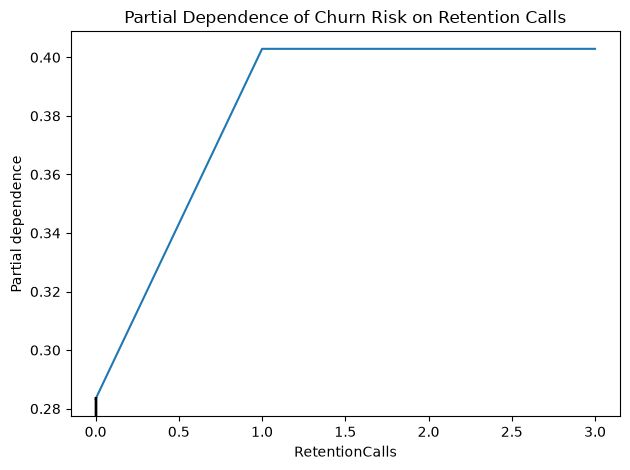

In [77]:
PartialDependenceDisplay.from_estimator(
    interpretation_pipeline,
    X_validation_pdp,
    features=["RetentionCalls"],
    kind="average",
    grid_resolution=20,
)

plt.title(
    "Partial Dependence of Churn Risk on Retention Calls"
)

plt.tight_layout()
plt.show()

### Retention-Feature Leakage Sensitivity Analysis

Retention-related variables may encode information generated after a customer has already exhibited churn intent. Because the dataset does not provide sufficient temporal information to establish when these interactions occurred relative to the prediction point, model performance is evaluated both with and without retention-related predictors.

In [78]:
retention_columns = [
    column
    for column in X_train_processed.columns
    if "retention" in column.lower()
]

retention_columns

['RetentionCalls', 'RetentionOffersAccepted', 'MadeCallToRetentionTeam']

In [79]:
X_train_no_retention = X_train_processed.drop(
    columns=retention_columns
)

X_validation_no_retention = X_validation_processed.drop(
    columns=retention_columns
)

print(
    "Training predictors:",
    X_train_no_retention.shape[1]
)

print(
    "Validation predictors:",
    X_validation_no_retention.shape[1]
)

Training predictors: 61
Validation predictors: 61


In [80]:
numeric_columns_no_retention = (
    X_train_no_retention
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_columns_no_retention = (
    X_train_no_retention
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print(
    "Numeric:",
    len(numeric_columns_no_retention)
)

print(
    "Categorical:",
    len(categorical_columns_no_retention)
)

print(
    "Total:",
    len(numeric_columns_no_retention)
    + len(categorical_columns_no_retention)
)

Numeric: 40
Categorical: 21
Total: 61


In [81]:
preprocessor_no_retention = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_columns_no_retention
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_columns_no_retention
        ),
    ]
)

gb_no_retention = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_no_retention
        ),
        (
            "to_dense",
            FunctionTransformer(to_dense)
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=10,
                min_samples_leaf=60,
                l2_regularization=3.0,
                random_state=42,
            )
        ),
    ]
)

gb_no_retention.fit(
    X_train_no_retention,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('to_dense', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](61,)","['MonthlyRevenue','MonthlyMinutes','TotalRecurringCharge',..., 'HighOverage','LowUsageOlderEquipment','HighRiskHandset']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,61
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (d

In [82]:
no_retention_probabilities = (
    gb_no_retention.predict_proba(
        X_validation_no_retention
    )[:, 1]
)

no_retention_roc_auc = roc_auc_score(
    y_validation,
    no_retention_probabilities
)

no_retention_pr_auc = average_precision_score(
    y_validation,
    no_retention_probabilities
)

print("WITH RETENTION FEATURES")
print("-----------------------")
print(f"ROC-AUC: {gb_reg_roc_auc:.4f}")
print(f"PR-AUC:  {gb_reg_pr_auc:.4f}")

print()

print("WITHOUT RETENTION FEATURES")
print("--------------------------")
print(f"ROC-AUC: {no_retention_roc_auc:.4f}")
print(f"PR-AUC:  {no_retention_pr_auc:.4f}")

print()

print("PERFORMANCE CHANGE")
print("------------------")
print(
    f"ROC-AUC: "
    f"{no_retention_roc_auc - gb_reg_roc_auc:+.4f}"
)
print(
    f"PR-AUC:  "
    f"{no_retention_pr_auc - gb_reg_pr_auc:+.4f}"
)

WITH RETENTION FEATURES
-----------------------
ROC-AUC: 0.6641
PR-AUC:  0.4384

WITHOUT RETENTION FEATURES
--------------------------
ROC-AUC: 0.6621
PR-AUC:  0.4342

PERFORMANCE CHANGE
------------------
ROC-AUC: -0.0021
PR-AUC:  -0.0042


### Retention-Feature Sensitivity Result

Removing `RetentionCalls`, `RetentionOffersAccepted`, and
`MadeCallToRetentionTeam` resulted in only a small reduction in validation
performance:

- ROC-AUC decreased from 0.6641 to 0.6621.
- PR-AUC decreased from 0.4384 to 0.4342.

Because the dataset does not establish whether retention interactions occurred
before the intended prediction point, these variables were excluded from the
production-facing model to reduce potential temporal leakage. The minimal
performance reduction indicates that the model's predictive performance does
not depend materially on these retention-related variables.

In [83]:
no_retention_train_probabilities = (
    gb_no_retention.predict_proba(
        X_train_no_retention
    )[:, 1]
)

no_retention_train_roc_auc = roc_auc_score(
    y_train,
    no_retention_train_probabilities
)

no_retention_train_pr_auc = average_precision_score(
    y_train,
    no_retention_train_probabilities
)

print(f"Training ROC-AUC:   {no_retention_train_roc_auc:.4f}")
print(f"Validation ROC-AUC: {no_retention_roc_auc:.4f}")
print(
    f"ROC-AUC gap:        "
    f"{no_retention_train_roc_auc - no_retention_roc_auc:.4f}"
)

print()

print(f"Training PR-AUC:    {no_retention_train_pr_auc:.4f}")
print(f"Validation PR-AUC:  {no_retention_pr_auc:.4f}")
print(
    f"PR-AUC gap:         "
    f"{no_retention_train_pr_auc - no_retention_pr_auc:.4f}"
)

Training ROC-AUC:   0.7140
Validation ROC-AUC: 0.6621
ROC-AUC gap:        0.0519

Training PR-AUC:    0.5044
Validation PR-AUC:  0.4342
PR-AUC gap:         0.0702


In [84]:
production_threshold_results = []

for threshold in np.arange(0.10, 0.61, 0.01):

    predictions = (
        no_retention_probabilities >= threshold
    ).astype(int)

    production_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Precision": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "CustomersFlagged": predictions.sum(),
        "FlaggedPercent": predictions.mean() * 100,
    })

production_threshold_results = pd.DataFrame(
    production_threshold_results
)

production_best_f1 = production_threshold_results.loc[
    production_threshold_results["F1"].idxmax()
]

print("Retention-Free Highest-F1 Threshold")
print("-----------------------------------")
print(
    f"Threshold:         "
    f"{production_best_f1['Threshold']:.2f}"
)
print(
    f"Accuracy:          "
    f"{production_best_f1['Accuracy']:.4f}"
)
print(
    f"Precision:         "
    f"{production_best_f1['Precision']:.4f}"
)
print(
    f"Recall:            "
    f"{production_best_f1['Recall']:.4f}"
)
print(
    f"F1 Score:          "
    f"{production_best_f1['F1']:.4f}"
)
print(
    f"Customers Flagged: "
    f"{int(production_best_f1['CustomersFlagged']):,}"
)
print(
    f"Flagged Percent:   "
    f"{production_best_f1['FlaggedPercent']:.2f}%"
)

Retention-Free Highest-F1 Threshold
-----------------------------------
Threshold:         0.27
Accuracy:          0.5772
Precision:         0.3781
Recall:            0.7241
F1 Score:          0.4968
Customers Flagged: 4,226
Flagged Percent:   55.19%


## 14. Production Candidate Selection

The regularized Gradient Boosting classifier excluding retention-related
predictors was selected as the production candidate.

Although including retention-related variables produced slightly higher
validation performance, their temporal relationship to the intended prediction
point could not be established. Removing these variables reduced validation
ROC-AUC from 0.6641 to 0.6621 and PR-AUC from 0.4384 to 0.4342, representing
only a small predictive-performance tradeoff for a more defensible model
specification.

Final production-candidate configuration:

- Model: HistGradientBoostingClassifier
- Learning rate: 0.05
- Maximum iterations: 300
- Maximum leaf nodes: 10
- Minimum samples per leaf: 60
- L2 regularization: 3.0
- Predictors: 61
- Retention-related predictors excluded
- Validation ROC-AUC: 0.6621
- Validation PR-AUC: 0.4342
- F1-optimal validation threshold: 0.27

The test set remained untouched throughout model selection, regularization,
feature evaluation, leakage analysis, and threshold development.

In [85]:
production_capacity_results = []

for capacity in [0.10, 0.20, 0.30, 0.40]:

    threshold = np.quantile(
        no_retention_probabilities,
        1 - capacity
    )

    predictions = (
        no_retention_probabilities >= threshold
    ).astype(int)

    customers_flagged = predictions.sum()

    churners_captured = (
        (predictions == 1)
        & (y_validation.values == 1)
    ).sum()

    precision = precision_score(
        y_validation,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        predictions,
        zero_division=0
    )

    production_capacity_results.append({
        "TargetCapacity": capacity * 100,
        "Threshold": threshold,
        "CustomersFlagged": customers_flagged,
        "ChurnersCaptured": churners_captured,
        "Precision": precision,
        "ChurnCapturePercent": recall * 100,
        "Lift": precision / y_validation.mean(),
    })

production_capacity_results = pd.DataFrame(
    production_capacity_results
)

production_capacity_results.round({
    "TargetCapacity": 0,
    "Threshold": 3,
    "Precision": 4,
    "ChurnCapturePercent": 2,
    "Lift": 2,
})

,TargetCapacity,Threshold,CustomersFlagged,ChurnersCaptured,Precision,ChurnCapturePercent,Lift
0,10.0,0.432,766,401,0.5235,18.17,1.82
1,20.0,0.377,1532,698,0.4556,31.63,1.58
2,30.0,0.340,2297,970,0.4223,43.95,1.47
3,40.0,0.313,3063,1256,0.4101,56.91,1.42


In [86]:
X_test_no_retention = X_test_processed.drop(
    columns=retention_columns
)

print("Test shape:", X_test_no_retention.shape)
print(
    "Expected predictors:",
    X_train_no_retention.shape[1]
)

print(
    "Columns identical:",
    X_test_no_retention.columns.equals(
        X_train_no_retention.columns
    )
)

Test shape: (7658, 61)
Expected predictors: 61
Columns identical: True


In [87]:
test_probabilities = gb_no_retention.predict_proba(
    X_test_no_retention
)[:, 1]

In [88]:
final_threshold = 0.27

test_predictions = (
    test_probabilities >= final_threshold
).astype(int)

In [89]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

test_confusion = confusion_matrix(
    y_test,
    test_predictions
)

print("FINAL TEST PERFORMANCE")
print("----------------------")
print(f"Threshold: {final_threshold:.2f}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print(f"PR-AUC:    {test_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(test_confusion)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["No Churn", "Churn"],
        digits=4,
        zero_division=0,
    )
)

FINAL TEST PERFORMANCE
----------------------
Threshold: 0.27
Accuracy:  0.5763
Precision: 0.3779
Recall:    0.7277
F1 Score:  0.4974
ROC-AUC:   0.6738
PR-AUC:    0.4417

Confusion Matrix:
[[2807 2644]
 [ 601 1606]]

Classification Report:
              precision    recall  f1-score   support

    No Churn     0.8237    0.5150    0.6337      5451
       Churn     0.3779    0.7277    0.4974      2207

    accuracy                         0.5763      7658
   macro avg     0.6008    0.6213    0.5656      7658
weighted avg     0.6952    0.5763    0.5944      7658



## 15. Final Test Evaluation

After model selection, regularization, threshold analysis, feature
interpretation, and leakage sensitivity analysis were completed using only the
training and validation sets, the production candidate was evaluated once on
the previously untouched test set.

### Final Test Performance

- ROC-AUC: **0.6738**
- PR-AUC: **0.4417**
- Accuracy at threshold 0.27: **0.5763**
- Precision: **0.3779**
- Recall: **0.7277**
- F1 score: **0.4974**

At the validation-selected probability threshold of 0.27, the model identified
1,606 of 2,207 churners, corresponding to 72.77% recall.

The test ROC-AUC and PR-AUC were slightly higher than validation performance,
while precision, recall, and F1 remained highly consistent. This indicates
that the selected model generalized comparably to the held-out customer
population.

The 0.27 threshold represents the validation-set F1 operating point rather
than a universally optimal business threshold. In production, the operating
threshold can be adjusted according to retention-team capacity, intervention
cost, and the relative cost of false negatives and false positives.